# Multimodal Mental Health Tracker: Exploratory Data Analysis

Analyzing raw linguistic patterns and validate engineered features for the Ensemble Model.

## Step 1: Imports and Environment Setup

Importing all necessary libraries for data manipulation, visualization, and machine learning.

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import pyarrow
from collections import Counter
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

# Formatting for plots
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

## Step 2: Raw Data Profiling

Examining the dataset before any preprocessing to understand the "noise" and class distribution.

### a. Loading the Dataset

Loading the dataset and examining its structure.

In [16]:
# Load raw and processed data
df_raw = pd.read_csv('../data/raw/mental_health.csv')
df_processed = pd.read_csv('../data/processed/cleaned_mental_health.csv')

print(f"Total entries in raw dataset: {len(df_raw)}")
print(f"Columns: {df_raw.columns.tolist()}")

# Check for missing values
print("\nMissing values per column:")
print(df_raw.isnull().sum())

Total entries in raw dataset: 27977
Columns: ['text', 'label']

Missing values per column:
text     0
label    0
dtype: int64


### b. Class Distribution

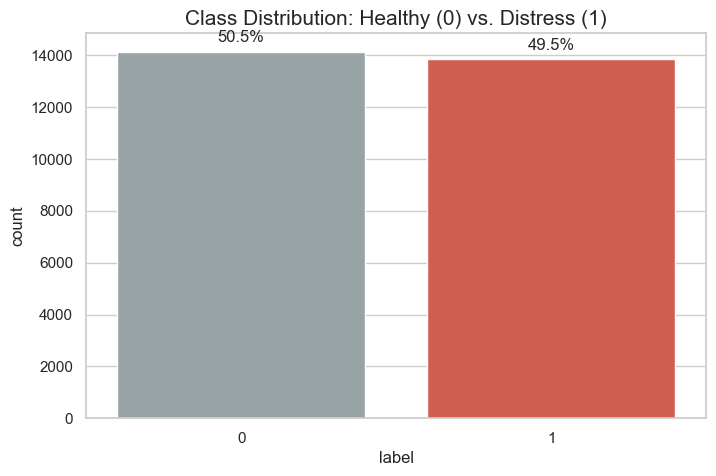

In [17]:
# Check for class imbalance
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df_raw, x='label', palette=['#95a5a6', '#e74c3c'])
plt.title("Class Distribution: Healthy (0) vs. Distress (1)", fontsize=15)

# Adding percentage labels on bars
total = len(df_raw)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', xytext=(0, 10), textcoords='offset points')
plt.show()

## Step 3: Linguistic Pattern Analysis

Does the length of a post or the choice of words vary significantly between categories?

### a. Text Length Analysis

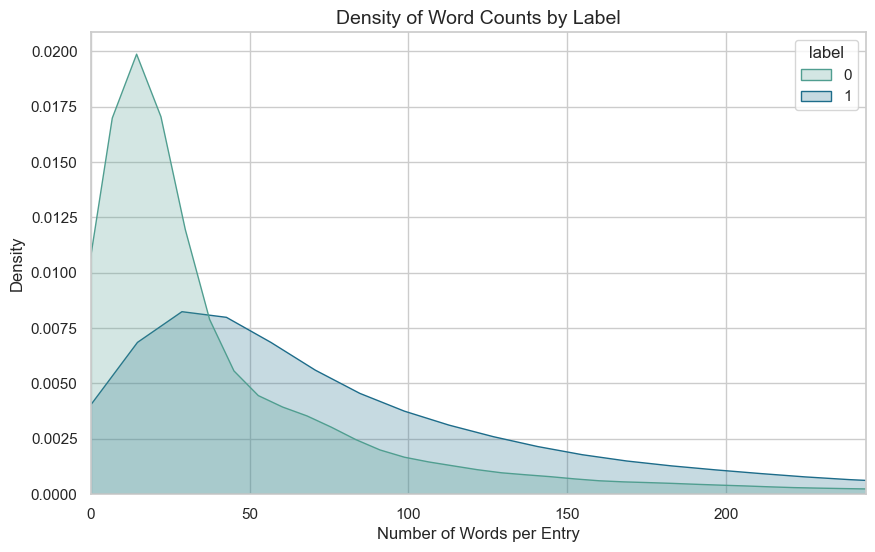

In [18]:
df_raw['word_count'] = df_raw['text'].str.split().str.len()

plt.figure(figsize=(10, 6))
sns.kdeplot(data=df_raw, x='word_count', hue='label', fill=True, common_norm=False, palette='crest')
plt.title("Density of Word Counts by Label", fontsize=14)
plt.xlabel("Number of Words per Entry")
plt.xlim(0, df_raw['word_count'].quantile(0.95)) # Focus on the majority of data
plt.show()

### b. The "Noise" Check

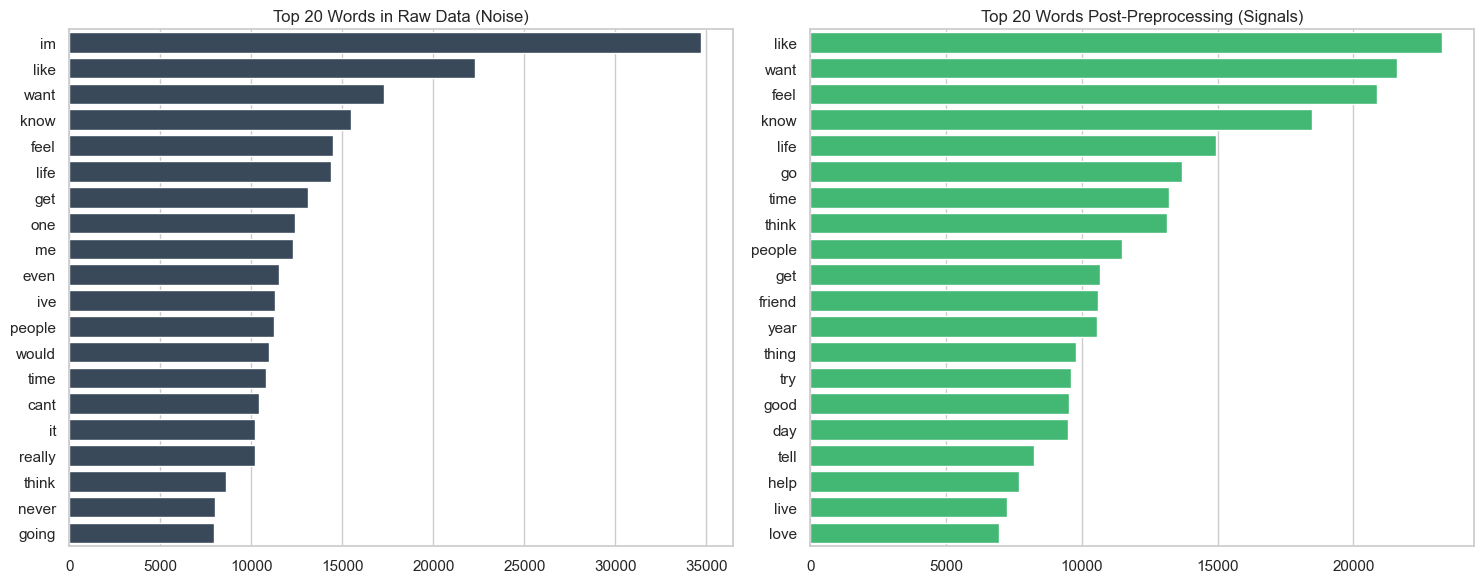

In [19]:
def plot_most_common(text_series, title, color):
    words = " ".join(text_series).split()
    most_common = Counter(words).most_common(20)
    words, counts = zip(*most_common)
    sns.barplot(x=list(counts), y=list(words), color=color)
    plt.title(title)

plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
plot_most_common(df_raw['text'], "Top 20 Words in Raw Data (Noise)", "#34495e")

plt.subplot(1, 2, 2)
plot_most_common(df_processed['cleaned_text'].dropna(), "Top 20 Words Post-Preprocessing (Signals)", "#2ecc71")
plt.tight_layout()
plt.show()

### Analysis of Preprocessing Impact

#### Linguistic Noise v/s Emotional Signals
This visualization confirms the effectiveness of the NLP Preprocessing Pipeline.

- **Raw Data (Left)**: The high frequency of stop-words and contractions (e.g., "im", "ive", "it") creates significant noise. These words appear frequently across both categories and offer zero predictive value for mental health classification.

- **Processed Data (Right)**: After Lemmatization and Stop-word removal, we observe a clear shift toward meaningful "action" and "state" words.

Keywords like "feel", "want", and "think" dominate the signal, which are critical for sentiment-based modeling.

The transition from "going" to its root form and the removal of numeric/special character noise ensures that the TF-IDF Vectorizer in the next phase will focus on high-entropy features rather than grammatical structure.

**Conclusion**: The preprocessing has successfully reduced the vocabulary size while increasing the "signal-to-noise" ratio, which is expected to improve the convergence and accuracy of our Ensemble Classifier.

## Step 4: Feature Validation

Loading the `final_feature_matrix.pkl` to see how the mathematical transformations (TF-IDF + Behavioral Features) represent the data.

### a. Loading the Feature Matrix

In [20]:
X, y = joblib.load('../data/processed/final_feature_matrix.pkl')
print(f"Matrix shape: {X.shape} (Observations, Features)")

Matrix shape: (27977, 5003) (Observations, Features)


### b. Behavioural Feature Correlation (The "I" Usage Theory)

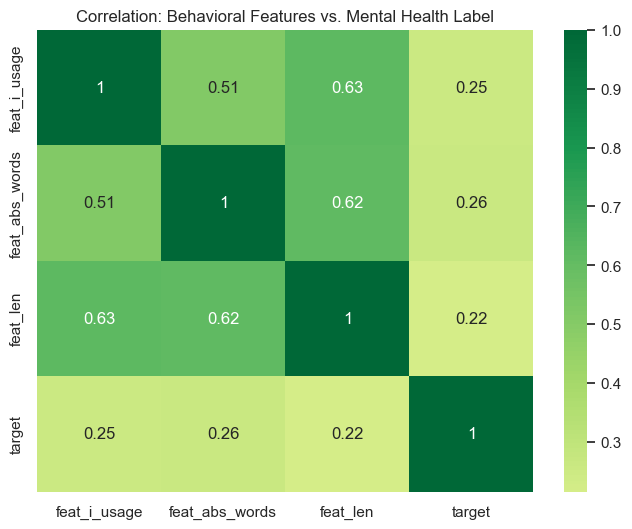

In [21]:
# Correlation between our custom features and the target
corr_cols = ['feat_i_usage', 'feat_abs_words', 'feat_len']
temp_df = X[corr_cols].copy()
temp_df['target'] = y.values

plt.figure(figsize=(8, 6))
sns.heatmap(temp_df.corr(), annot=True, cmap='RdYlGn', center=0)
plt.title("Correlation: Behavioral Features vs. Mental Health Label")
plt.show()

### Key Insights from the Heatmap

This correlation matrix validates our approach by showing how engineered linguistic features relate to the mental health status (Target).

- **Positive Correlation with Target**: We observe a consistent positive correlation (ranging from **0.22 to 0.26**) between the target label and our engineered features (`feat_i_usage`, `feat_abs_words`, and `feat_len`). While these coefficients might seem modest, in high-noise natural language data, they represent a significant predictive signal.

- **Validation of 'I-Usage' Theory**: The correlation of **0.25** for `feat_i_usage` confirms the psychological hypothesis that self-referential language increases with emotional distress.

- **Feature Inter-correlation**: There is a high correlation between `feat_len` and `feat_i_usage` (**0.63**), which is logical—the more one writes, the more opportunities there are for self-reference. However, because they are not perfectly correlated (1.0), each still provides unique information to the Ensemble Model.

**Conclusion**: These behavioral features provide a structured "numerical context" that complements the raw word-importance scores from the TF-IDF Vectorizer, allowing the ensemble to make more nuanced predictions than a simple text classifier could.

### c. Top TF-IDF Features (Word Cloud)

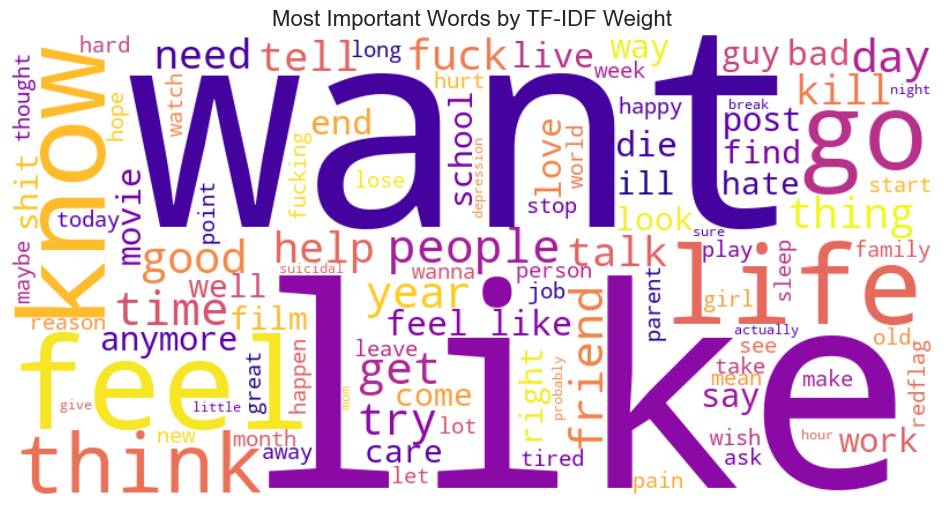

In [22]:
# Removing behavioral features to only visualize text tokens
text_features = X.drop(columns=['feat_i_usage', 'feat_abs_words', 'feat_len'])
mean_weights = text_features.mean().sort_values(ascending=False).head(100)

wordcloud = WordCloud(width=800, height=400, background_color='white', 
                      colormap='plasma', max_words=100).generate_from_frequencies(mean_weights)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Most Important Words by TF-IDF Weight", fontsize=16)
plt.show()